# Marketing ML Project

## Objectives
* Build a classifier that predicts wheter a person makes less than $50k or more than $50k given 40 demographic and employment related variables
* Create a segmentation model and demonstrate how the resulting groups differ from one another and how your client can use this model for marketing

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, log_loss
# from utils import load_and_clean_data

## Import dataset

In [5]:
# read column headers into a list
with open('data/census-bureau.columns', 'r') as f:
    columns = [line.strip() for line in f]

# import main data
df = pd.read_csv('data/census-bureau.data', header=None, names=columns)

# display first few rows
df.head()

,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.


In [ ]:
columns

### Notes
* "Not in universe" used; a distinct category rather than "missing" data
* "?" indicates missing data
* "weight indicates relative distribution of people in general population that each record represents due to stratified sampling"
* complex decision boundary -> motivation for gradient boosted decision tree model classification task
* weighted k-means clustering for segmentation task since weights are important in identifying statistically significant segments

## Data Visualizations

In [ ]:
# preprocessing
df_clean = df.replace('?', 'NA') # handle missing values


In [ ]:
# feature engineering
df_clean['total_financial_flow'] = df_clean['capital gains'] - df_clean['capital losses'] + df_clean['dividends from stocks'] 

df_clean['life_productivity'] = df_clean['age'] * df_clean['weeks worked in year']

df_clean['employment_stability'] = df_clean['class of worker'].astype(str) + "_" + df_clean['education'].astype(str) # career category

# prime earning window where >$50K is statistically concentrated
df_clean['is_peak_earning_age'] = df_clean['age'].between(35, 55).astype(int)

In [ ]:
# separate features and convert target to binary
y = df_clean['label'].apply(lambda x:1 if '50000+' in str(x) else 0).values 
weights = df_clean['weight'].values # extract weights
X = df_clean.drop(['label', 'weight', 'year'], axis=1) # prepare features

In [ ]:
# encode categorical features as integers for xgboost
categorical = X.select_dtypes(include=['object']).columns
label_encoders = {}
for cat in categorical:
    le = LabelEncoder()
    X[cat] = le.fit_transform(X[cat].astype(str))
    label_encoders[cat] = le

In [ ]:
# temp dataframe that matches encoded feature set + target
X_vis = X.copy()
X_vis['target'] = y

# calculate correlation matrix
corr_matrix = X_vis.corr()

In [ ]:
# feature correlation with target
target_corr = corr_matrix['target'].drop('target').sort_values(ascending=True)

plt.figure(figsize=(10, 12))
target_corr.plot(kind='barh', color='skyblue')
plt.title('Feature Correlation with Target (Income > $50K)', fontsize=14, pad=15)
plt.xlabel('Pearson Correlation Coefficient($r$)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
# plt.savefig('feature_target_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# correlation matrix
plt.figure(figsize=(22, 18))

sns.heatmap(
    corr_matrix, 
    annot=False,
    cmap='coolwarm',
    square=True,
    vmin=-1, vmax=1,
    cbar_kws={'shrink': 0.7, 'label': 'Pearson Correlation Coefficient ($r$)'}
)

plt.title('Global Correlation Map Matrix')

# label rotation and font sixes for readability
plt.xticks(rotation=90, fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
# plt.savefig(global_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## Classification Task

In [ ]:
# split data
# 80% train & validation / 20% test
X_temp, X_test, y_temp, y_test, w_temp, w_test = train_test_split(
    X, y, weights, test_size=0.20, random_state=42, stratify=y
)

# take 20% from 80% split earlier for validation (total: 60% train/20% test/20% val)
X_train, X_val, y_train, y_val, w_train, w_val = train_test_split(
    X_temp, y_temp, w_temp, test_size=0.25, random_state=42, stratify=y_temp
)

In [ ]:
# train model
# scale_pos_weight helps with class imbalance
ratio = np.sum(y == 0) / np.sum(y == 1)

# grid search setup
weighted_logloss = make_scorer(
    log_loss,
    response_method='predict_proba',
    greater_is_better=False,
)

param_grid = {
    'max_depth': [6, 8, 10, 12],
    'learning_rate': [0.03, 0.05],
    'n_estimators': [100, 200, 300],
    'colsample_bytree': [0.7, 0.8]
    
}

# base classifier setup
base_classifier = XGBClassifier(
    scale_pos_weight=ratio,
    subsample=0.8, # prevents rows from forcing overfit
    random_state=42,
    eval_metric=['logloss']
)

grid_search = GridSearchCV(
    estimator=base_classifier,
    param_grid=param_grid,
    scoring=weighted_logloss,
    cv=3,
    verbose=1,
    n_jobs=1,
)

grid_search.fit(
    X_temp, y_temp, 
    sample_weight=w_temp
)
print('Optimal Hyperparameters:', grid_search.best_params_)

# grab best settings and initialize deep execution run
best_settings = grid_search.best_params_
best_settings['scale_pos_weight'] = ratio
best_settings['subsample'] = 0.8
best_settings['random_state'] = 42
best_settings['eval_metric'] = ['logloss', 'error']
best_settings['early_stopping_rounds'] = 50
best_settings['n_estimators'] = 1000

classifier = XGBClassifier(**best_settings)

classifier.fit(
    X_train, y_train,
    sample_weight=w_train, 
    eval_set=[(X_train, y_train), (X_val, y_val)],
    sample_weight_eval_set=[w_train, w_val],
    verbose=10
)

In [ ]:
# validation & evaluation
print("Final Evaluation")
y_pred = classifier.predict(X_test)
print(classification_report(y_test, y_pred, sample_weight=w_test)) # use sample_weight in report to reflect population distribution

# confusion matrix visualization
cm = confusion_matrix(y_test, y_pred, sample_weight=w_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Predicted <50k', 'Predicted >50k'],
            yticklabels=['Actual <50k', 'Actual >50k'])
plt.title('Weighted Confusion Matrix (Population Scale)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


important_features = pd.Series(classifier.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top 10 Predictive Variables for Income")
print(important_features.head(10))

### Notes
#### Implementation:
* class 0 high precision (0.99) high recall (0.91)
* class 1 low precision (0.38) acceptable recall (0.83)
* overall accuracy 0.90

ways to adjust:
1) adjust classification threshold
2) lower/remove scale_pos_weight, may decrease recall
3) feature engineering

---

#### Fix 1: adjust classification threshold(0.75)
Result: precision of class 0 decreased (0.98) and recall increased (0.96), increases precision (0.54) of class 1 but lowers recall (0.69), overall accuracy 0.94

#### Fix 2: slower learning_rate 0.05 -> 0.03, max_depth 6 -> 7, scale_pos_weight=1, added max_delta_step=1
Result: Overly conservative model, never predicts 1

#### Fix 2b: sqrt ratio, added subsample=0.8, added colsample_bytree=0.8*
Result: class 0 precision 0.96, recall 0.99; class 1 precision 0.69, recall 0.38; overall accuracy 0.95

#### Fix 3: feature engineering (total_financial_flow, life_productivity, employment_stability, is_peak_earning_age)
Result: class 0 precision same, recall +0.1; class 1 precision +0.2, recall -0.2; overall accuracy 0.91
* improved fundamental predictablility
* model uses engineered metrics to spot high earners

### Next Steps
* explore cross validation
* options:
    1) use the model as is, captures majority of the available wealth in the population; option comprehensive customer discovery and retention -> capture
    2) more feature engineering 
    3) reintroduce custom probability threshold for higher precision; option for direct marketing and targeted campaigns -> conversion

## Segmentation Task

In [6]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

In [7]:
# preprocessing
df_km = df.replace('?', 'NA') # handle missing values

# separate metadata from features
X_raw = df_km.drop(['label', 'weight', 'year'], axis=1).copy()
w_km = df_km['weight'].values

# isolate continuous numerical features for scaling
numeric_features = [
    'age', 'wage per hour', 'capital gains', 'capital losses', 'dividends from stocks',
    'num persons worked for employer', 'weeks worked in year'
]

# remaining treated as categorical column for one-hot encoding
categorical_features = [col for col in X_raw.columns if col not in numeric_features]

# construct parallel processing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='NA')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_features)
    ]
)

X_scaled_km = preprocessor.fit_transform(X_raw)
X_scaled_km.shape

(199523, 508)

K=1, Inertia:770019624.35
K=2, Inertia:643222559.29
K=3, Inertia:598032055.45
K=4, Inertia:543933688.97
K=5, Inertia:502124377.14
K=6, Inertia:480084666.97
K=7, Inertia:450878518.30
K=8, Inertia:436560104.76
K=9, Inertia:415572326.95
K=10, Inertia:415071792.38
K=11, Inertia:387692669.00
K=12, Inertia:367947256.60
K=13, Inertia:357865205.34
K=14, Inertia:351461518.76


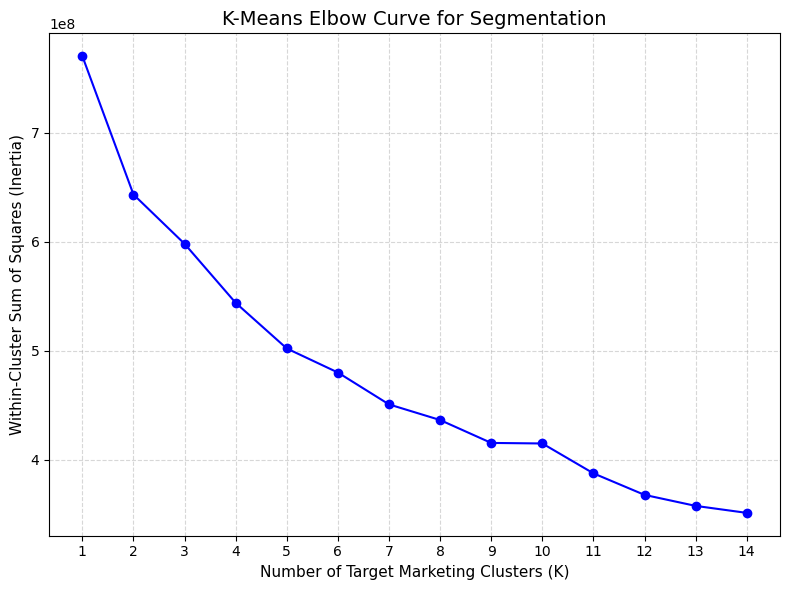

In [8]:
# find optimal number of clusters
# 10% representative sample to compute elbow curve efficiently
sample_size = int(len(X_scaled_km) * 0.10)
np.random.seed(42)
sample_indices = np.random.choice(len(X_scaled_km), size=sample_size, replace=False)

X_sample = X_scaled_km[sample_indices]
w_sample = w_km[sample_indices]

# run elbow loop
inertia_scores = []
k_range = range(1, 15)

for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=100)
    kmeans_test.fit(X_sample, sample_weight=w_sample)
    inertia_scores.append(kmeans_test.inertia_)
    print(f'K={k}, Inertia:{kmeans_test.inertia_:.2f}')
    
# plot elbow curve
plt.figure(figsize=(8, 6))
plt.plot(k_range, inertia_scores, marker='o', linestyle='-', color='blue')
plt.title('K-Means Elbow Curve for Segmentation', fontsize=14)
plt.xlabel('Number of Target Marketing Clusters (K)', fontsize=11)
plt.ylabel('Within-Cluster Sum of Squares (Inertia)', fontsize=11)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
# inertia delta
inertia_drops = np.diff(inertia_scores)
plt.figure(figsize=(8, 4))
plt.bar(range(2, 15), -inertia_drops, color='blue')
plt.title('Inertia Drop Per Additional Cluster')
plt.xlabel('Clustering Step (K)')
plt.ylabel('Reduction in WCSS')
plt.xticks(range(2, 15))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [9]:
selected_k = 5
k_means_final = KMeans(n_clusters=selected_k, random_state=42, n_init=10, max_iter=300)

# fit final model with selected k on entire population
k_means_final.fit(X_scaled_km, sample_weight=w_km)

# assign cluster labels to unscaled dataframe
df_km['cluster_id'] = k_means_final.labels_

# calculate population-weighted averages for each cluster
cluster_profiles = df_km.groupby('cluster_id')[numeric_features].mean()
cluster_profiles = cluster_profiles.T

print('Weighted Averages Per Cluster:\n', cluster_profiles.round(2))

Weighted Averages Per Cluster:
 cluster_id                            0     1        2       3       4
age                               38.44  8.06    44.28   57.55   38.28
wage per hour                    111.75  0.10    74.17    0.00  107.95
capital gains                    442.05  0.74  9314.90  146.20  400.09
capital losses                     0.40  0.00  1757.86    0.47    0.34
dividends from stocks            175.26  0.80  1353.58  383.50  171.41
num persons worked for employer    3.78  0.05     3.45    0.24    3.63
weeks worked in year              44.98  0.21    42.21    1.46   44.43


In [10]:
marketing_categories = ['education', 'marital stat', 'class of worker', 'major occupation code', 'sex']
print('Dominant Categorical Traits Per Cluster')
# calculate the most common text lable for each category within each cluster
for cat in marketing_categories:
    print(f'\nMost Commmon {cat.title()}:')
    for cluster in range(5):
        cluster_data = df_km[df_km['cluster_id'] == cluster]
        # find category with highest sum of population weights
        top_category = cluster_data.groupby(cat)['weight'].sum().idxmax()
        print(f'Cluster {cluster}: {top_category}')

Dominant Categorical Traits Per Cluster

Most Commmon Education:
Cluster 0: High school graduate
Cluster 1: Children
Cluster 2: High school graduate
Cluster 3: High school graduate
Cluster 4: High school graduate

Most Commmon Marital Stat:
Cluster 0: Married-civilian spouse present
Cluster 1: Never married
Cluster 2: Married-civilian spouse present
Cluster 3: Married-civilian spouse present
Cluster 4: Married-civilian spouse present

Most Commmon Class Of Worker:
Cluster 0: Private
Cluster 1: Not in universe
Cluster 2: Private
Cluster 3: Not in universe
Cluster 4: Private

Most Commmon Major Occupation Code:
Cluster 0: Adm support including clerical
Cluster 1: Not in universe
Cluster 2: Professional specialty
Cluster 3: Not in universe
Cluster 4: Adm support including clerical

Most Commmon Sex:
Cluster 0: Male
Cluster 1: Male
Cluster 2: Male
Cluster 3: Female
Cluster 4: Male


In [11]:
# calculate real-world population size of each group
cluster_sizes = df_km.groupby('cluster_id')['weight'].sum()
print('\nActual Population Size Per Cluster:')
print(cluster_sizes.map('{:,.0f}'.format))


Actual Population Size Per Cluster:
cluster_id
0    87,064,767
1    90,303,894
2     7,579,266
3    75,635,917
4    86,662,049
Name: weight, dtype: object


In [12]:
# custom age brackets to see the generational split
age_bins = [0, 17, 29, 54, 100]
age_labels = ['Youth (0-17)', 'Young Adults (18-29)', 'Peak Career (30-54)', 'Seniors (55+)']

df_km['age_group'] = pd.cut(df_km['age'], bins=age_bins, labels=age_labels)

# weighted cross-tabulation table
generational_mix = pd.crosstab(
    index=df_km['age_group'],
    columns=df_km['cluster_id'],
    values=df_km['weight'],
    aggfunc='sum'
).fillna(0)

print("Generational Representation in Each Group")
print(generational_mix.map('{:,.0f}'.format))

Generational Representation in Each Group
cluster_id                     0           1          2           3  \
age_group                                                             
Youth (0-17)           1,831,925  84,735,586    139,423     188,044   
Young Adults (18-29)  23,314,546     380,637  1,210,045  10,408,194   
Peak Career (30-54)   51,534,745           0  4,502,354  18,874,471   
Seniors (55+)         10,383,552           0  1,727,444  46,165,208   

cluster_id                     4  
age_group                         
Youth (0-17)           1,641,607  
Young Adults (18-29)  24,104,982  
Peak Career (30-54)   50,629,375  
Seniors (55+)         10,286,084  


## Resources
https://xgboost.readthedocs.io/en/release_3.2.0/tutorials/model.html

https://xgboost.readthedocs.io/en/stable/parameter.html

https://medium.com/data-science/stop-saying-precision-and-recall-to-business-leaders-f17082ab5052

https://www.adpresearch.com/research/the-wage-lifecycle-is-more-complex-than-you-think

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html